# Examples
In this section example use cases of `libsbgnpy` are provided.

In [1]:
from IPython.display import Image, display
import os
import tempfile

## Create SBGN
The example demonstrates how to create a `Sbgn` document from scratch. This includes creation of the following objects.

- `Map`: SBGN map
- `Bbox`: bounding boxes
- `Glyph`: glyph (nodes)
- `Arc`: arc (edges)

The full map consists of a simple reaction catalysed via `ADH1` which converts `Ethanol + NAD+ --> Ethanal + NADH + H+`.

<?xml version="1.0" encoding="UTF-8"?>
<sbgn xmlns="http://sbgn.org/libsbgn/0.3">
  <map language="process description">
    <bbox x="0" y="0" w="363" h="253"/>
    <glyph class="simple chemical" orientation="horizontal" id="glyph1">
      <label text="Ethanol"/>
      <bbox x="40" y="120" w="60" h="60"/>
    </glyph>
    <glyph class="simple chemical" orientation="horizontal" id="glyph_ethanal">
      <label text="Ethanal"/>
      <bbox x="220" y="110" w="60" h="60"/>
    </glyph>
    <glyph class="macromolecule" orientation="horizontal" id="glyph_adh1">
      <label text="ADH1"/>
      <bbox x="106" y="20" w="108" h="60"/>
    </glyph>
    <glyph class="simple chemical" orientation="horizontal" id="glyph_h">
      <label text="H+"/>
      <bbox x="220" y="190" w="60" h="60"/>
    </glyph>
    <glyph class="simple chemical" orientation="horizontal" id="glyph_nad">
      <label text="NAD+"/>
      <bbox x="40" y="190" w="60" h="60"/>
    </glyph>
    <glyph class="simple chemical" orie

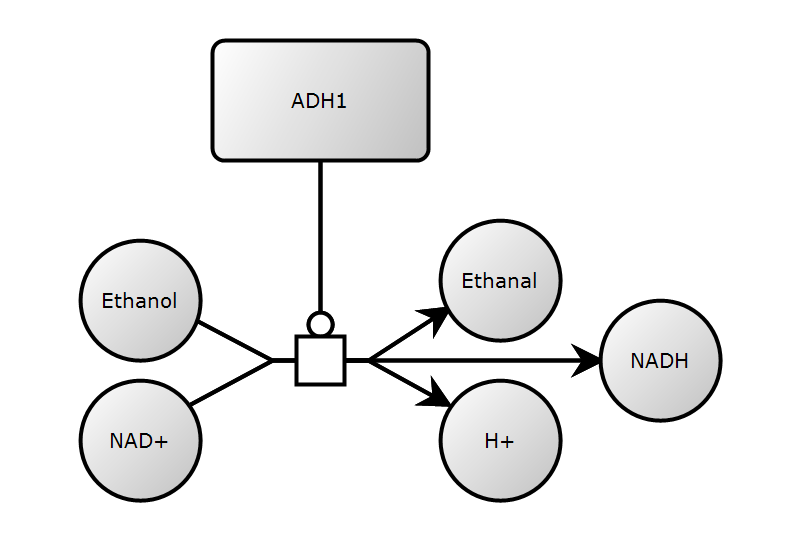

In [2]:
from libsbgnpy import *

# create new map
map = Map(
	language=MapLanguage.PROCESS_DESCRIPTION,
	bbox=Bbox(x=0, y=0, w=363, h=253),
)
sbgn = Sbgn(map=[map])

# create glyphs and add to map
map.glyph.extend([
	Glyph(
		class_value=GlyphClass.SIMPLE_CHEMICAL,
		id="glyph1",
		label=Label(text="Ethanol"),
		bbox=Bbox(x=40, y=120, w=60, h=60),
	),
	Glyph(
		class_value=GlyphClass.SIMPLE_CHEMICAL,
		id="glyph_ethanal",
		label=Label(text="Ethanal"),
		bbox=Bbox(x=220, y=110, w=60, h=60),
	),
	Glyph(
		class_value=GlyphClass.MACROMOLECULE,
		id="glyph_adh1",
		label=Label(text="ADH1"),
		bbox=Bbox(x=106, y=20, w=108, h=60),
	),
	Glyph(
		class_value=GlyphClass.SIMPLE_CHEMICAL,
		id="glyph_h",
		label=Label(text="H+"),
		bbox=Bbox(x=220, y=190, w=60, h=60),
	),
	Glyph(
		class_value=GlyphClass.SIMPLE_CHEMICAL,
		id="glyph_nad",
		label=Label(text="NAD+"),
		bbox=Bbox(x=40, y=190, w=60, h=60),
	),
	Glyph(
		class_value=GlyphClass.SIMPLE_CHEMICAL,
		id="glyph_nadh",
		label=Label(text="NADH"),
		bbox=Bbox(x=300, y=150, w=60, h=60),
	),
	# glyph with ports (process)
	Glyph(
		class_value=GlyphClass.PROCESS,
		id="pn1",
		orientation=GlyphOrientation.HORIZONTAL,
		bbox=Bbox(x=148, y=168, w=24, h=24),
		port=[
			Port(x=136, y=180, id="pn1.1"),
			Port(x=184, y=180, id="pn1.2"),
		],
	)
])

# arcs
# create arcs and set the start and end points
map.arc.extend([
	Arc(
		class_value=ArcClass.CONSUMPTION,
		source="glyph1",
		target="pn1.1",
		id="a01",
		start=Arc.Start(x=98, y=160),
		end=Arc.End(x=136, y=180),
	),
	Arc(
		class_value=ArcClass.PRODUCTION,
		source="pn1.2",
		target="glyph_nadh",
		id="a02",
		start=Arc.Start(x=184, y=180),
		end=Arc.End(x=300, y=180),
	),
	Arc(
		class_value=ArcClass.CATALYSIS,
		source="glyph_adh1",
		target="pn1",
		id="a03",
		start=Arc.Start(x=160, y=80),
		end=Arc.End(x=160, y=168),
	),
	Arc(
		class_value=ArcClass.PRODUCTION,
		source="pn1.2",
		target="glyph_h",
		id="a04",
		start=Arc.Start(x=184, y=180),
		end=Arc.End(x=224, y=202),
	),
	Arc(
		class_value=ArcClass.PRODUCTION,
		source="pn1.2",
		target="glyph_ethanal",
		id="a05",
		start=Arc.Start(x=184, y=180),
		end=Arc.End(x=224, y=154),
	),
	Arc(
		class_value=ArcClass.CONSUMPTION,
		source="glyph_nad",
		target="pn1.1",
		id="a06",
		start=Arc.Start(x=95, y=202),
		end=Arc.End(x=136, y=180),
	),
])

# write SBGN to file
f_out = tempfile.NamedTemporaryFile(suffix=".sbgn")
write_sbgn_to_file(sbgn, f_out.name)

# show xml
console.print(write_sbgn_to_string(sbgn))

# render SBGN
f_png = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
render_sbgn(sbgn, image_file=f_png.name, file_format="png")

# show the image
display(Image(f_png.name, width=300))

# cleanup
f_png.close()
os.unlink(f_png.name)

## Iterate Arcs & Glyphs
Example for iterating over glyphs and arcs in given SBGN file

In [3]:
from libsbgnpy import *

# Map
sbgn: Sbgn = read_sbgn_from_file("adh.sbgn")
map: Map = sbgn.map[0]

# Map
console.print(f"Map: {map.language}, BBox: {map.bbox}")
console.rule()

# Glyphs
for g in map.glyph:
    console.print(
        f"Glyph '{g.id}' of class '{g.class_value}' and label '{g.label}'."
    )
console.rule()

# Arcs
for a in map.arc:
    console.print(f"Arc '{a.id}' with class '{a.class_value}'.")

Map: MapLanguage.PROCESS_DESCRIPTION, BBox: Bbox(notes=None, extension=None, 
x=0.0, y=0.0, w=363.0, h=253.0)
────────────────────────────────────────────────────────────────────────────────
Glyph 'glyph1' of class 'GlyphClass.SIMPLE_CHEMICAL' and label 
'Label(notes=None, extension=None, bbox=None, text='Ethanol')'.
Glyph 'glyph_ethanal' of class 'GlyphClass.SIMPLE_CHEMICAL' and label 
'Label(notes=None, extension=None, bbox=None, text='Ethanal')'.
Glyph 'glyph_adh1' of class 'GlyphClass.MACROMOLECULE' and label 
'Label(notes=None, extension=None, bbox=None, text='ADH1')'.
Glyph 'glyph_h' of class 'GlyphClass.SIMPLE_CHEMICAL' and label 
'Label(notes=None, extension=None, bbox=None, text='H+')'.
Glyph 'glyph_nad' of class 'GlyphClass.SIMPLE_CHEMICAL' and label 
'Label(notes=None, extension=None, bbox=None, text='NAD+')'.
Glyph 'glyph_nadh' of class 'GlyphClass.SIMPLE_CHEMICAL' and label 
'Label(notes=None, extension=None, bbox=None, text='NADH')'.
Glyph 'pn1' of class 'GlyphClass.PROCE

## SBGN notes
The optional SBGN element named 'notes', present on every major SBGN
component type, is intended as a place for storing optional
information intended to be seen by humans.  An example use of the
'notes' element would be to contain formatted user comments about the
model element in which the 'notes' element is enclosed.  Every object
derived directly or indirectly from type SBase can have a separate
value for 'notes', allowing users considerable freedom when adding
comments to their models.

The format of 'notes' elements must be XHTML 1.0 (http://www.w3.org/1999/xhtml).

### Write SBGN notes

In [4]:
from libsbgnpy import *

# create map
map = Map(language=MapLanguage.PROCESS_DESCRIPTION)
sbgn = Sbgn(map=[map])

# create glyph
g = Glyph(
    id="g1",
    class_value=GlyphClass.MACROMOLECULE,
    label=Label(text="INSR"),
    bbox=Bbox(x=100, y=100, w=80, h=40),
)
map.glyph.append(g)

# set notes
g.notes = Sbgnbase.Notes(
    w3_org_1999_xhtml_element=[
        """<body xmlns="http://www.w3.org/1999/xhtml">
This is an example note describing the INSR glyph.
</body>""",
        """<body xmlns="http://www.w3.org/1999/xhtml">
A second note with more information
</body>""",
    ]
)

console.print(write_sbgn_to_string(sbgn))

<?xml version="1.0" encoding="UTF-8"?>
<sbgn xmlns="http://sbgn.org/libsbgn/0.3">
  <map language="process description">
    <glyph class="macromolecule" orientation="horizontal" id="g1">
      <notes>&lt;body xmlns="http://www.w3.org/1999/xhtml"&gt;
This is an example note describing the INSR glyph.
&lt;/body&gt;</notes>&lt;body xmlns="http://www.w3.org/1999/xhtml"&gt;
A second note with more information
&lt;/body&gt;<label text="INSR"/>
      <bbox x="100" y="100" w="80" h="40"/>
    </glyph>
  </map>
</sbgn>



### Read SBGN notes
SBGN notes can be read via the `get_notes` function which returns a `Notes` instance. We just display the note we wrote before on one of the glyphs.

In [5]:
map: Map = sbgn.map[0]

for g in map.glyph:
    if g.notes:
        console.print(g.id)
        console.print(g.notes.w3_org_1999_xhtml_element)

g1
[
    '<body xmlns="http://www.w3.org/1999/xhtml">\nThis is an example note 
describing the INSR glyph.\n</body>',
    '<body xmlns="http://www.w3.org/1999/xhtml">\nA second note with more 
information\n</body>'
]


## SBGN extension
SBGN allows to write extension information. This can be any well-formed XML content.
Whereas Notes is a container for content to be shown directly to humans, Extension is a container for
optional software-generated content not meant to be shown to humans. Every SBGN object can
have its own Extension object instance. In XML, the Extension content type is any, allowing essentially
arbitrary well-formed XML data content.

### Write SBGN extension

In [6]:
sbgn = Sbgn()
map = Map(language=MapLanguage.PROCESS_DESCRIPTION)
sbgn.map.append(map)
extension = Sbgnbase.Extension()
extension.any_element.append("""<renderInformation id="example" programName="SBML Layout" programVersion="3.0"
 xmlns="http://projects.eml.org/bcb/sbml/render/level2">
    <listOfColorDefinitions>
    <colorDefinition id="yelloComp" value="#ffffccff" />
    <colorDefinition id="grayComp" value="#e0e0e0ff" />
    <colorDefinition id="orange" value="#fa9e2fff" />
    <colorDefinition id="blue" value="#2958acff" />
    <colorDefinition id="green" value="#378f5cff" />
    <colorDefinition id="Color_0" value="#969696" />
    <colorDefinition id="Color_1" value="#ff9900" />
    <colorDefinition id="Color_2" value="#000000" />			
    </listOfColorDefinitions>
    <listOfGradientDefinitions>
    <linearGradient x1="0%" y1="0%" z1="0%" x2="100%" y2="0%" z2="100%" id="LinearGradient_0" spreadMethod="reflect">
        <stop offset="0%" stop-color="#ccffff" />
        <stop offset="100%" stop-color="#ffffff" />
    </linearGradient>
    <linearGradient x1="0%" y1="0%" z1="0%" x2="100%" y2="0%" z2="100%" id="OrangeGradient_0" spreadMethod="reflect">
        <stop offset="0%" stop-color="#ffffff" />
        <stop offset="100%" stop-color="#fa9e2fff" />
    </linearGradient>
    <linearGradient x1="0%" y1="0%" z1="0%" x2="100%" y2="0%" z2="100%" id="BlueGradient_0" spreadMethod="reflect">
        <stop offset="0%" stop-color="#ffffff" />
        <stop offset="100%" stop-color="#2958acff" />
    </linearGradient>
    <linearGradient x1="0%" y1="0%" z1="0%" x2="100%" y2="0%" z2="100%" id="GreenGradient_0" spreadMethod="reflect">
        <stop offset="0%" stop-color="#ffffff" />
        <stop offset="100%" stop-color="#378f5cff" />
    </linearGradient>
    </listOfGradientDefinitions>
    <listOfStyles>
    <style idList="glyph0 glyph2 glyph14 glyph34 ">
        <g stroke="Color_2" stroke-width="5" fill="yelloComp"  />			
    </style>
    <style idList="glyph1">
        <g stroke="Color_2" stroke-width="5" fill="grayComp"  />			
    </style>
    </listOfStyles>
</renderInformation>""")
map.extension = extension

console.print(write_sbgn_to_string(sbgn))

<?xml version="1.0" encoding="UTF-8"?>
<sbgn xmlns="http://sbgn.org/libsbgn/0.3">
  <map language="process description">
    <extension>&lt;renderInformation id="example" programName="SBML Layout" 
programVersion="3.0"
 xmlns="http://projects.eml.org/bcb/sbml/render/level2"&gt;
    &lt;listOfColorDefinitions&gt;
    &lt;colorDefinition id="yelloComp" value="#ffffccff" /&gt;
    &lt;colorDefinition id="grayComp" value="#e0e0e0ff" /&gt;
    &lt;colorDefinition id="orange" value="#fa9e2fff" /&gt;
    &lt;colorDefinition id="blue" value="#2958acff" /&gt;
    &lt;colorDefinition id="green" value="#378f5cff" /&gt;
    &lt;colorDefinition id="Color_0" value="#969696" /&gt;
    &lt;colorDefinition id="Color_1" value="#ff9900" /&gt;
    &lt;colorDefinition id="Color_2" value="#000000" /&gt;                      
    &lt;/listOfColorDefinitions&gt;
    &lt;listOfGradientDefinitions&gt;
    &lt;linearGradient x1="0%" y1="0%" z1="0%" x2="100%" y2="0%" z2="100%" 
id="LinearGradient_0" spreadMethod=

### Read SBGN extension
We now read the map extension information written in the example above.

In [7]:
# map is a container for the glyphs and arcs
map: Map = sbgn.map[0]

extension: Sbgnbase.Extension = map.extension
if extension:
    console.print(extension)
    console.print(str(extension.any_element[0]))

Extension(
    any_element=[
        '<renderInformation id="example" programName="SBML Layout" 
programVersion="3.0"\n xmlns="http://projects.eml.org/bcb/sbml/render/level2">\n
<listOfColorDefinitions>\n    <colorDefinition id="yelloComp" value="#ffffccff" 
/>\n    <colorDefinition id="grayComp" value="#e0e0e0ff" />\n    
<colorDefinition id="orange" value="#fa9e2fff" />\n    <colorDefinition 
id="blue" value="#2958acff" />\n    <colorDefinition id="green" 
value="#378f5cff" />\n    <colorDefinition id="Color_0" value="#969696" />\n    
<colorDefinition id="Color_1" value="#ff9900" />\n    <colorDefinition 
id="Color_2" value="#000000" />\t\t\t\n    </listOfColorDefinitions>\n    
<listOfGradientDefinitions>\n    <linearGradient x1="0%" y1="0%" z1="0%" 
x2="100%" y2="0%" z2="100%" id="LinearGradient_0" spreadMethod="reflect">\n     
<stop offset="0%" stop-color="#ccffff" />\n        <stop offset="100%" 
stop-color="#ffffff" />\n    </linearGradient>\n    <linearGradient x1="0%" 
y1="0

## Read & Write SBGN
Helper functions for reading, writing and printing SBGN are provided in the `utils` module.

### Write SBGN  to string
The SBGN string can be generated from the `sbgn` object via

In [8]:
sbgn_str = write_sbgn_to_string(sbgn)
console.print(sbgn_str)

<?xml version="1.0" encoding="UTF-8"?>
<sbgn xmlns="http://sbgn.org/libsbgn/0.3">
  <map language="process description">
    <extension>&lt;renderInformation id="example" programName="SBML Layout" 
programVersion="3.0"
 xmlns="http://projects.eml.org/bcb/sbml/render/level2"&gt;
    &lt;listOfColorDefinitions&gt;
    &lt;colorDefinition id="yelloComp" value="#ffffccff" /&gt;
    &lt;colorDefinition id="grayComp" value="#e0e0e0ff" /&gt;
    &lt;colorDefinition id="orange" value="#fa9e2fff" /&gt;
    &lt;colorDefinition id="blue" value="#2958acff" /&gt;
    &lt;colorDefinition id="green" value="#378f5cff" /&gt;
    &lt;colorDefinition id="Color_0" value="#969696" /&gt;
    &lt;colorDefinition id="Color_1" value="#ff9900" /&gt;
    &lt;colorDefinition id="Color_2" value="#000000" /&gt;                      
    &lt;/listOfColorDefinitions&gt;
    &lt;listOfGradientDefinitions&gt;
    &lt;linearGradient x1="0%" y1="0%" z1="0%" x2="100%" y2="0%" z2="100%" 
id="LinearGradient_0" spreadMethod=

### Write SBGN to file

In [9]:
f_out = tempfile.NamedTemporaryFile(suffix=".sbgn", delete=False)

# write SBGN
write_sbgn_to_file(sbgn=sbgn, f=f_out.name)

f_out.close()
os.unlink(f_out.name)

### Read SBGN from file

In [10]:
sbgn = read_sbgn_from_file("glycolysis.sbgn")

## Render SBGN
SBGN images can be renderd via the `render` module.

SBGN rendered: /tmp/tmpjxap0t82.png


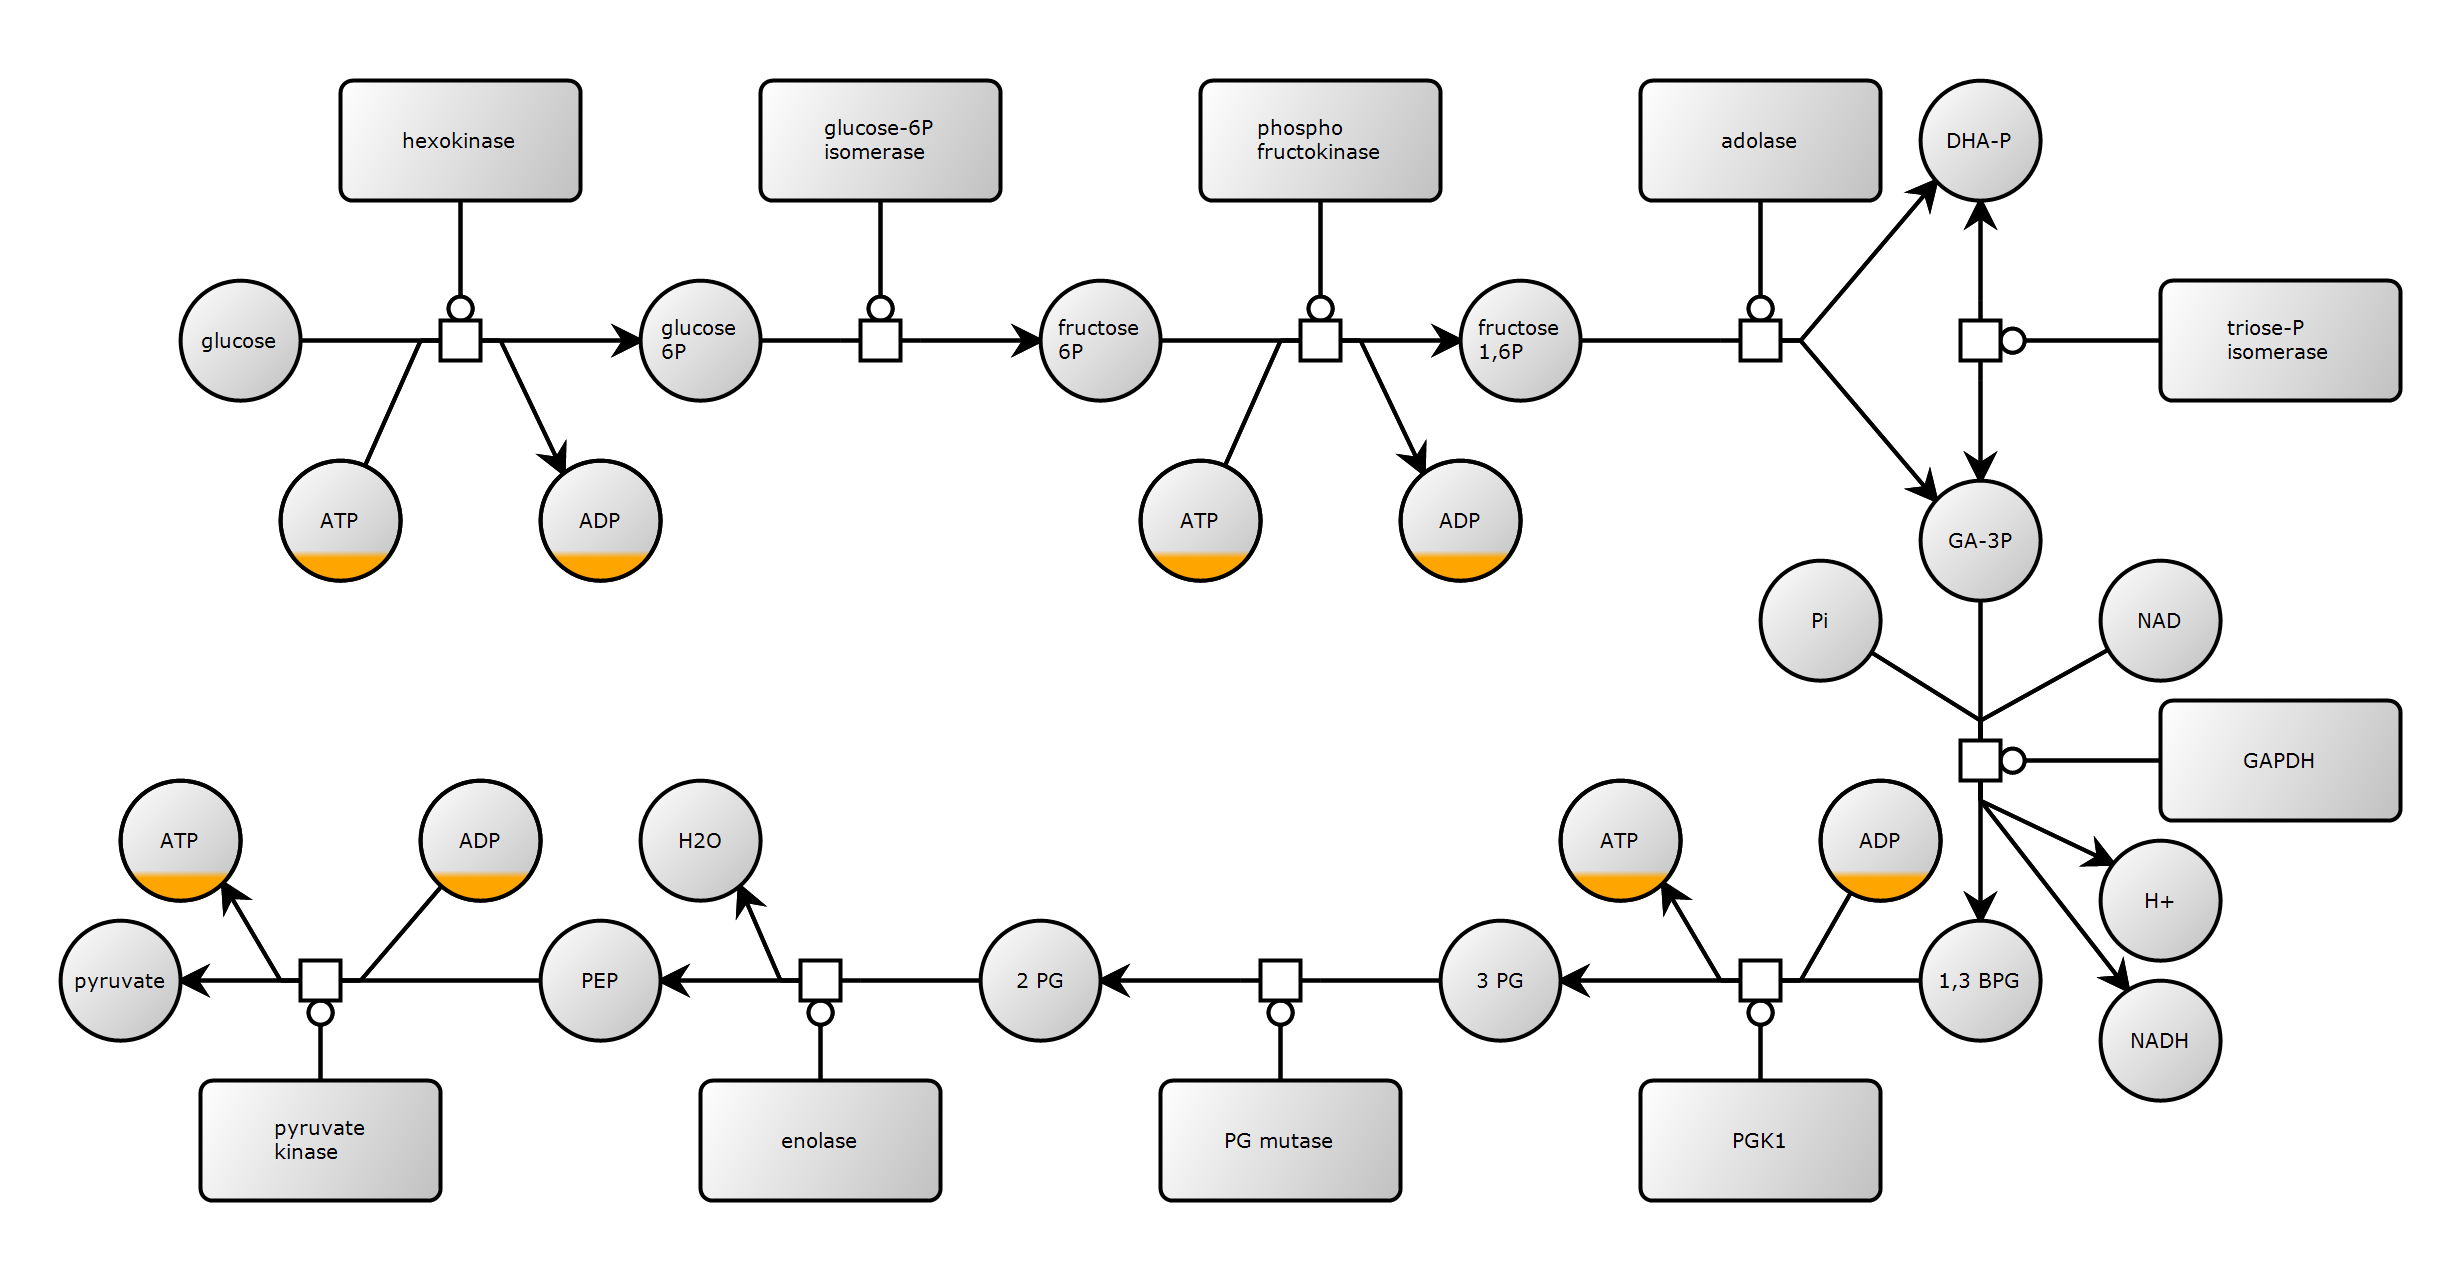

In [11]:
# Render SBGN
sbgn = read_sbgn_from_file("glycolysis.sbgn")
f_png = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
render_sbgn(sbgn, image_file=f_png.name, 
                   file_format="png")
display(Image(f_png.name, width=500))
f_png.close()
os.unlink(f_png.name)

## Write special characters
SBGN supports UTF-8 and all characters can be used in the labels. 

SBGN rendered: /tmp/tmp596x7f3z.png


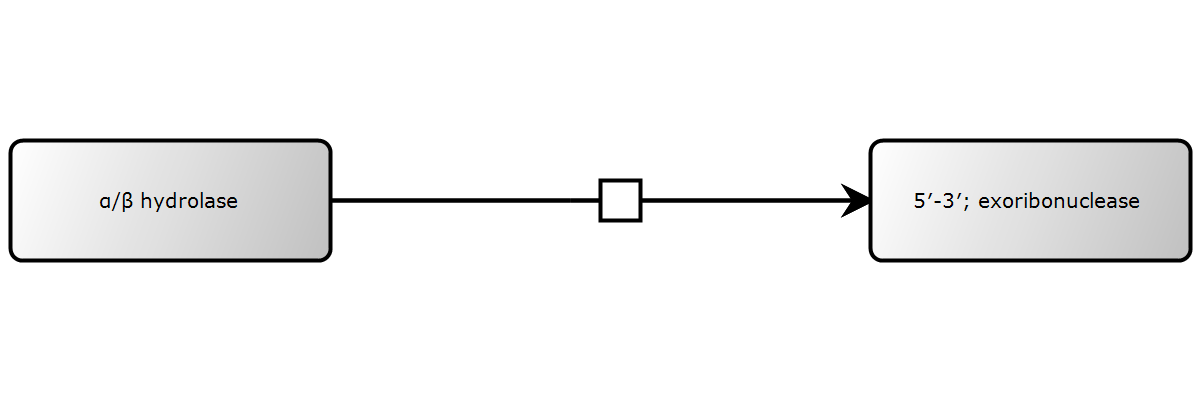

In [12]:
map = Map(
    language=MapLanguage.PROCESS_DESCRIPTION,
    bbox=Bbox(x=0, y=0, w=600, h=200),
)
sbgn = Sbgn(map=[map])

# create some glyphs
map.glyph = [
    # simple glyph
    Glyph(
        class_value=GlyphClass.MACROMOLECULE,
        id="glyph1",
        label=Label(text="α/β hydrolase"),
        bbox=Bbox(x=5, y=70, w=160, h=60),
    ),
    Glyph(
        class_value=GlyphClass.MACROMOLECULE,
        id="glyph2",
        label=Label(text="5′-3′; exoribonuclease"),
        bbox=Bbox(x=435, y=70, w=160, h=60),
    ),
    Glyph(
        class_value=GlyphClass.PROCESS,
        id="glyph3",
        bbox=Bbox(x=300, y=90, w=20, h=20),
        port=[
            Port(id="glyph3.1", x=285, y=100),
            Port(id="glyph3.2", x=315, y=100),
        ],
    ),
]
map.arc = [
    Arc(
        id="arc1",
        class_value=ArcClass.CONSUMPTION,
        source="glyph1",
        target="glyph3.1",
        start=Arc.Start(x=165, y=100),
        end=Arc.End(x=285, y=100),
    ),
    Arc(
        id="arc2",
        class_value=ArcClass.PRODUCTION,
        source="glyph3.2",
        target="glyph2",
        start=Arc.Start(x=315, y=100),
        end=Arc.End(x=435, y=100),
    ),
]
f_png = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
render_sbgn(sbgn, image_file=f_png.name, 
                   file_format="png")
display(Image(f_png.name, width=500))
f_png.close()
os.unlink(f_png.name)

## Render information
Render information can be encoded directly with the libsbgnpy library. The following example shows how to do this.

In [13]:
map = Map(language=MapLanguage.PROCESS_DESCRIPTION)
sbgn = Sbgn(map=[map])

# create glyph
map.glyph = [
    Glyph(
        id="glyph1",
        class_value=GlyphClass.MACROMOLECULE,
        label=Label(text="INSR"),
        bbox=Bbox(x=100, y=100, w=80, h=40),
    ),
    Glyph(
        id="glyph2",
        class_value=GlyphClass.SIMPLE_CHEMICAL,
        label=Label(text="ATP"),
        bbox=Bbox(x=200, y=100, w=80, h=40),
    ),
    Glyph(
        id="glyph3",
        class_value=GlyphClass.SIMPLE_CHEMICAL,
        label=Label(text="glucose"),
        bbox=Bbox(x=300, y=100, w=80, h=40),
    ),
]

"""
Information to write:
<renderInformation id="example" programName="libsbgnpy" programVersion="1.0.0"
 xmlns="http://www.sbml.org/sbml/level3/version1/render/version1">
    <listOfColorDefinitions>
    <colorDefinition id="color0" value="#969696" />
    <colorDefinition id="color1" value="#ff9900" />
    </listOfColorDefinitions>

    <listOfGradientDefinitions>
        <linearGradient x1="0%" y1="0%" x2="100%" y2="0%" id="gradient0">
            <stop offset="0%" stop-color="#ccffff" />
            <stop offset="100%" stop-color="#ffffff" />
        </linearGradient>
    </listOfGradientDefinitions>

    <listOfStyles>
    <style idList="glyph1 glyph2">
        <g stroke="color0" stroke-width="5" fill="color1" />
    </style>
    <style idList="glyph3">
        <g stroke="color1" stroke-width="2" fill="gradient0" />
    </style>
    </listOfStyles>
</renderInformation>
"""
render_info = RenderInformation(
    id="example",
    program_name="libsbgnpy",
    program_version="1.0.0",
    list_of_color_definitions=ListOfColorDefinitions(
        color_definition=[
            ColorDefinition(id="color0", value="#969696"),
            ColorDefinition(id="color1", value="#ff9900"),
        ]
    ),
    list_of_gradient_definitions=ListOfGradientDefinitions(
        linear_gradient=[
            LinearGradient(
                id="gradient0",
                x1="0%",
                y1="0%",
                x2="100%",
                y2="0%",
                stop=[
                    LinearGradient.Stop(offset="0%", stop_color="#ccffff"),
                    LinearGradient.Stop(offset="100%", stop_color="#ffffff"),
                ],
            )
        ]
    ),
    list_of_styles=ListOfStyles(
        [
            Style(
                id_list="glyph1 glyph2",
                g=G(stroke="color0", stroke_width=5, fill="color1"),
            ),
            Style(
                id_list="glyph3",
                g=G(stroke="color1", stroke_width=2, fill="gradient0"),
            ),
        ]
    ),
)
# set extension
xml_str = write_render_to_string(render_info=render_info)
console.print(xml_str)
map.extension = Sbgn.Extension([xml_str])
# console.print(write_sbgn_to_string(sbgn))

<?xml version="1.0" encoding="UTF-8"?>
<ns0:renderInformation 
xmlns:ns0="http://www.sbml.org/sbml/level3/version1/render/version1" 
ns0:id="example" ns0:programName="libsbgnpy" ns0:programVersion="1.0.0">
  <ns0:listOfColorDefinitions>
    <ns0:colorDefinition ns0:id="color0" ns0:value="#969696"/>
    <ns0:colorDefinition ns0:id="color1" ns0:value="#ff9900"/>
  </ns0:listOfColorDefinitions>
  <ns0:listOfGradientDefinitions>
    <ns0:linearGradient ns0:id="gradient0" ns0:x1="0%" ns0:x2="100%" ns0:y1="0%"
ns0:y2="0%">
      <ns0:stop ns0:offset="0%" ns0:stop-color="#ccffff"/>
      <ns0:stop ns0:offset="100%" ns0:stop-color="#ffffff"/>
    </ns0:linearGradient>
  </ns0:listOfGradientDefinitions>
  <ns0:listOfStyles>
    <ns0:style ns0:idList="glyph1 glyph2">
      <ns0:g ns0:stroke="color0" ns0:stroke-width="5" ns0:fill="color1"/>
    </ns0:style>
    <ns0:style ns0:idList="glyph3">
      <ns0:g ns0:stroke="color1" ns0:stroke-width="2" ns0:fill="gradient0"/>
    </ns0:style>
  </ns0:lis

## Clone marker example
Clone markers can be set via the `Glyph.Clone()` on glyphs. In the example we are adding clone markers to NAD+, NADH and H+ as cofactors.

SBGN rendered: /tmp/tmpy5kf5i_f.png


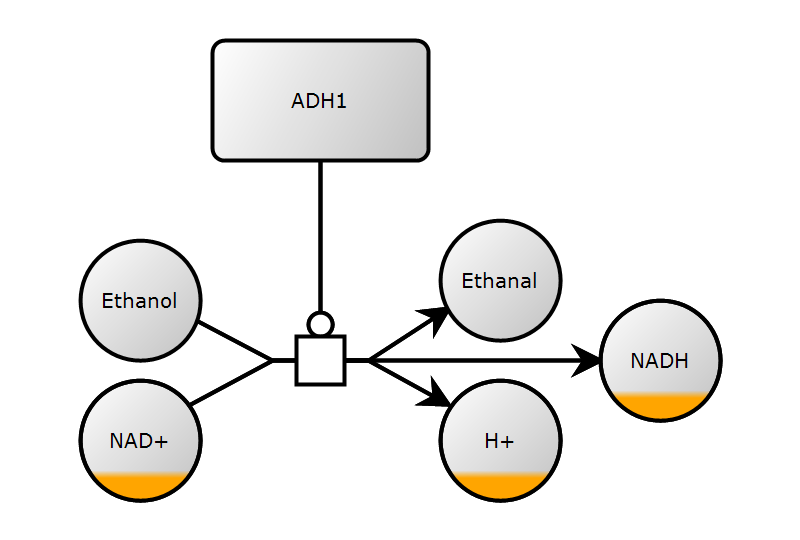

In [14]:
"""Clone marker example."""
from libsbgnpy import *
# create new map
map = Map(
    language=MapLanguage.PROCESS_DESCRIPTION,
    bbox=Bbox(x=0, y=0, w=363, h=253),
)
# add map to new sbgn
sbgn = Sbgn(map=[map])

# create glyphs and add to map
map.glyph.extend(
    [
        Glyph(
            class_value=GlyphClass.SIMPLE_CHEMICAL,
            id="glyph1",
            label=Label(text="Ethanol"),
            bbox=Bbox(x=40, y=120, w=60, h=60),
        ),
        Glyph(
            class_value=GlyphClass.SIMPLE_CHEMICAL,
            id="glyph_ethanal",
            label=Label(text="Ethanal"),
            bbox=Bbox(x=220, y=110, w=60, h=60),
        ),
        Glyph(
            class_value=GlyphClass.MACROMOLECULE,
            id="glyph_adh1",
            label=Label(text="ADH1"),
            bbox=Bbox(x=106, y=20, w=108, h=60),
        ),
        Glyph(
            class_value=GlyphClass.SIMPLE_CHEMICAL,
            id="glyph_h",
            label=Label(text="H+"),
            bbox=Bbox(x=220, y=190, w=60, h=60),
            clone=Glyph.Clone(),  # clone marker
        ),
        Glyph(
            class_value=GlyphClass.SIMPLE_CHEMICAL,
            id="glyph_nad",
            label=Label(text="NAD+"),
            bbox=Bbox(x=40, y=190, w=60, h=60),
            clone=Glyph.Clone(),  # clone marker
        ),
        Glyph(
            class_value=GlyphClass.SIMPLE_CHEMICAL,
            id="glyph_nadh",
            label=Label(text="NADH"),
            bbox=Bbox(x=300, y=150, w=60, h=60),
            clone=Glyph.Clone(),  # clone marker
        ),
        # glyph with ports (process)
        Glyph(
            class_value=GlyphClass.PROCESS,
            id="pn1",
            orientation=GlyphOrientation.HORIZONTAL,
            bbox=Bbox(x=148, y=168, w=24, h=24),
            port=[
                Port(x=136, y=180, id="pn1.1"),
                Port(x=184, y=180, id="pn1.2"),
            ],
        ),
    ]
)

# arcs
# create arcs and set the start and end points
map.arc.extend(
    [
        Arc(
            class_value=ArcClass.CONSUMPTION,
            source="glyph1",
            target="pn1.1",
            id="a01",
            start=Arc.Start(x=98, y=160),
            end=Arc.End(x=136, y=180),
        ),
        Arc(
            class_value=ArcClass.PRODUCTION,
            source="pn1.2",
            target="glyph_nadh",
            id="a02",
            start=Arc.Start(x=184, y=180),
            end=Arc.End(x=300, y=180),
        ),
        Arc(
            class_value=ArcClass.CATALYSIS,
            source="glyph_adh1",
            target="pn1",
            id="a03",
            start=Arc.Start(x=160, y=80),
            end=Arc.End(x=160, y=168),
        ),
        Arc(
            class_value=ArcClass.PRODUCTION,
            source="pn1.2",
            target="glyph_h",
            id="a04",
            start=Arc.Start(x=184, y=180),
            end=Arc.End(x=224, y=202),
        ),
        Arc(
            class_value=ArcClass.PRODUCTION,
            source="pn1.2",
            target="glyph_ethanal",
            id="a05",
            start=Arc.Start(x=184, y=180),
            end=Arc.End(x=224, y=154),
        ),
        Arc(
            class_value=ArcClass.CONSUMPTION,
            source="glyph_nad",
            target="pn1.1",
            id="a06",
            start=Arc.Start(x=95, y=202),
            end=Arc.End(x=136, y=180),
        ),
    ]
)

f_png = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
render_sbgn(sbgn, image_file=f_png.name, 
                   file_format="png")
display(Image(f_png.name, width=500))
f_png.close()
os.unlink(f_png.name)